# Defence Spending and Redistribution

Additional project to my LSE paper "What Political Factors Determine the Extent of Redistribution in Democratic Societies?" (Romer–Meltzer–Richard model extended with Effective Political Voice, Electoral Rules, and Defence Spending).

The project uses and visualizes World Bank data on defence spending and government expenditure to explore the defence-welfare relationship discussed in the paper's Third Correction. Built with `pandas` / `matplotlib` / `seaborn`.

```bash
```

In [1]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

COUNTRIES = ["POL", "DEU", "FRA", "ITA", "SWE", "ESP"]
START_YEAR, END_YEAR = 2000, 2024

Matplotlib is building the font cache; this may take a moment.


## 1. World Bank

In [2]:
wdi_series = {
    "MS.MIL.XPND.GD.ZS": "defence_pct_gdp",
    "NE.CON.GOVT.ZS": "govt_expenditure_pct_gdp",
}

wb_frames = []
for code, label in wdi_series.items():
    df = wb.data.DataFrame(code, COUNTRIES, range(START_YEAR, END_YEAR + 1), labels=False)
    df = df.reset_index().melt(id_vars="economy", var_name="year", value_name=label)
    df["year"] = df["year"].str.replace("YR", "").astype(int)
    df = df.rename(columns={"economy": "country"})
    wb_frames.append(df.set_index(["country", "year"]))

wb_data = pd.concat(wb_frames, axis=1).reset_index()
wb_data.head()


/var/folders/th/xp20l_4x0wj9g0xrg81p911w0000gn/T/ipykernel_73949/2227679275.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["year"] = df["year"].str.replace("YR", "").astype(int)
/var/folders/th/xp20l_4x0wj9g0xrg81p911w0000gn/T/ipyke

,country,year,defence_pct_gdp,govt_expenditure_pct_gdp
0,DEU,2000,1.344216,19.438126
1,ESP,2000,1.725518,16.633903
2,FRA,2000,2.092189,22.567173
3,ITA,2000,1.733397,17.823341
4,POL,2000,1.819045,17.987439


## 2. Clean & merge

In [5]:
merged = wb_data.dropna(subset=["defence_pct_gdp"])
merged.head()


,country,year,defence_pct_gdp,govt_expenditure_pct_gdp
0,DEU,2000,1.344216,19.438126
1,ESP,2000,1.725518,16.633903
2,FRA,2000,2.092189,22.567173
3,ITA,2000,1.733397,17.823341
4,POL,2000,1.819045,17.987439


## 3. Visualize

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/relational.py:300: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sub_data[f"{other}min"] = np.nan
/Library/Frameworks/Python.framework/Versions/3.14/lib/

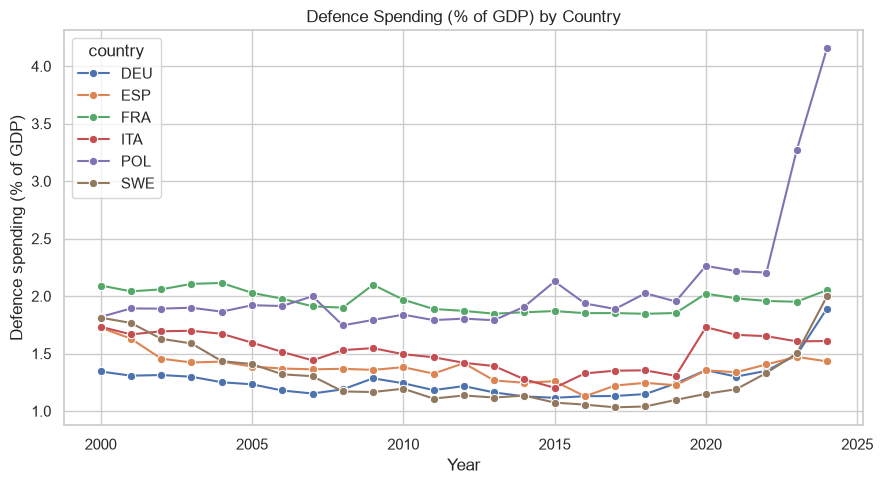

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=merged, x="year", y="defence_pct_gdp", hue="country", marker="o", ax=ax)
ax.set_title("Defence Spending (% of GDP) by Country")
ax.set_xlabel("Year")
ax.set_ylabel("Defence spending (% of GDP)")
plt.tight_layout()
plt.savefig("defence_spending.png", dpi=150)
plt.show()


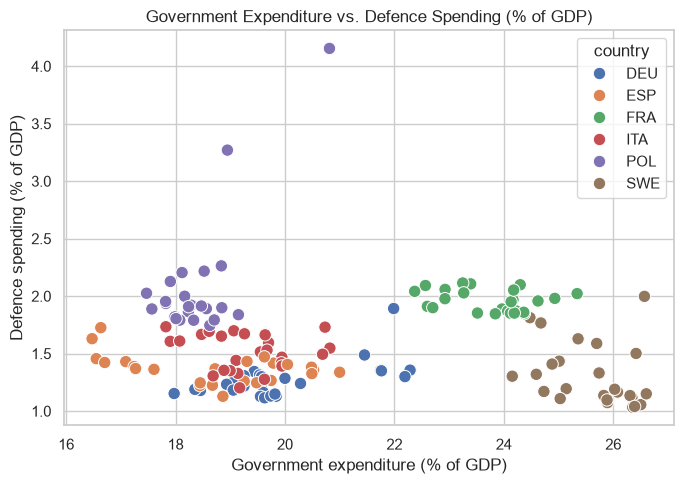

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=merged, x="govt_expenditure_pct_gdp", y="defence_pct_gdp",
    hue="country", s=80, ax=ax,
)
ax.set_title("Government Expenditure vs. Defence Spending (% of GDP)")
ax.set_xlabel("Government expenditure (% of GDP)")
ax.set_ylabel("Defence spending (% of GDP)")
plt.tight_layout()
plt.savefig("expenditure_vs_defence.png", dpi=150)
plt.show()


## 4. Notes
Across the sample, defence spending shows no simple positive relationship with overall
government expenditure, if anything, a mild trade-off. Poland combines relatively low
government expenditure (~18-19% of GDP, the lowest in the sample alongside Italy and Spain)
with consistently elevated and, since 2022, sharply rising defence spending, culminating in
a spike to roughly 4% of GDP by the end of the sample, consistent with the post-2022 shift in regional security posture. 
By contrast, France sustains the highest government expenditure (~24% of GDP) with comparatively stable,
moderate defence spending (~2% of GDP) throughout the period, while Sweden and Germany,
despite similarly high government expenditure, keep defence spending among the lowest in
the sample until a visible uptick after 2020. This pattern is consistent with the RMR
extension in my LSE paper: countries with larger redistributive/welfare commitments do not
automatically convert that fiscal capacity into higher defence spending, suggesting defence
spending responds more to external security shocks and electoral/political constraints than
to the size of the state's overall redistributive footprint.